In [1]:
# Do all importing and setup here
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import glob
import importlib.util
from pathlib import Path
from scipy.ndimage import uniform_filter

import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "training").exists():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "training").exists():
            repo_root = p
            break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from training.config_utils import load_and_prepare_config
from inference import infer_iso_embedding_sr_attn as inf
from utils.symmetry_utils import resolve_symmetry
from utils import reduce_to_fz_min_angle

# -------------------------------------------------------------
# Optional dependency: scikit-image for SSIM
# -------------------------------------------------------------
# --- SSIM dependency check ---
try:
    from skimage.metrics import structural_similarity as sk_ssim
    SKIMAGE_AVAILABLE = True
except ImportError:
    SKIMAGE_AVAILABLE = False
    sk_ssim = None

In [2]:
# Section 2: Quaternion utilities
def normalize_quat(q, eps=1e-12):
    q = np.asarray(q, dtype=np.float64)
    orig_shape = q.shape
    if q.size == 0:
        return q
    # ensure last axis is 4
    if q.shape[-1] != 4:
        raise ValueError('Quaternion arrays must have last axis size 4')
    n = np.linalg.norm(q.reshape(-1, 4), axis=1).reshape(q.shape[:-1] + (1,))
    return (q / (n + eps))

def quat_conjugate(q):
    q = np.asarray(q)
    return q * np.array([1.0, -1.0, -1.0, -1.0])

def quat_mul(a, b):
    # Hamilton product (w, x, y, z) ordering
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape[-1] != 4 or b.shape[-1] != 4:
        raise ValueError('Input quaternions must have shape (...,4)')
    w1, x1, y1, z1 = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    w2, x2, y2, z2 = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    w = w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2
    x = w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2
    y = w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2
    z = w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2
    return np.stack((w, x, y, z), axis=-1)

def quat_dot(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.sum(a * b, axis=-1)

def axis_angle_to_quat(axis, angle_rad):
    axis = np.asarray(axis, dtype=np.float64)
    axis = axis / (np.linalg.norm(axis) + 1e-16)
    w = np.cos(angle_rad / 2.0)
    xyz = axis * np.sin(angle_rad / 2.0)
    return np.concatenate(([w], xyz))

def quat_to_rotmat(q):
    q = normalize_quat(q)
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    # broadcast friendly component expressions
    xx = x * x; yy = y * y; zz = z * z
    xy = x * y; xz = x * z; yz = y * z
    wx = w * x; wy = w * y; wz = w * z
    R = np.empty(q.shape[:-1] + (3, 3), dtype=np.float64)
    R[..., 0, 0] = 1 - 2 * (yy + zz)
    R[..., 0, 1] = 2 * (xy - wz)
    R[..., 0, 2] = 2 * (xz + wy)
    R[..., 1, 0] = 2 * (xy + wz)
    R[..., 1, 1] = 1 - 2 * (xx + zz)
    R[..., 1, 2] = 2 * (yz - wx)
    R[..., 2, 0] = 2 * (xz - wy)
    R[..., 2, 1] = 2 * (yz + wx)
    R[..., 2, 2] = 1 - 2 * (xx + yy)
    return R

def quat_from_z_rotation(angle_rad):
    return np.array([np.cos(angle_rad / 2.0), 0.0, 0.0, np.sin(angle_rad / 2.0)])

def small_rotation_quat(noise_deg):
    # random small rotation quaternion for synthetic tests
    ang = np.deg2rad(noise_deg)
    # random axis
    axis = np.random.normal(size=3)
    axis = axis / (np.linalg.norm(axis) + 1e-16)
    return axis_angle_to_quat(axis, ang)

In [3]:
# Section 3: Symmetry helpers (reuse repo implementations)
def get_symmetry(sym=None):
    """Return an orix symmetry object for the requested group name (default HCP / D6h).
    Accepts either a canonical string (e.g. 'D6h', 'hcp', '6/mmm') or an orix Symmetry object.
    """
    if sym is None:
        assert False, "Symmetry must be specified as a string or orix Symmetry object"
    return resolve_symmetry(sym)


def reduce_to_fz(q_map, sym=None, return_op_map=False, **kwargs):
    """Wrapper around the repo's `reduce_to_fz_min_angle` implementation.
    q_map: quaternion array (4,*spatial) or (*spatial,4)
    sym: symmetry name or orix Symmetry object
    return_op_map: if True also return operator index map
    """
    sym_obj = sym if not isinstance(sym, str) else resolve_symmetry(sym)
    try:
        out = reduce_to_fz_min_angle(q_map, sym_obj, return_op_map=return_op_map, **kwargs)
    except Exception:
        # surface error to caller
        raise
    return out


In [4]:
# -------------------------------------------------------------
# Maximum misorientation depending on crystal symmetry
# -------------------------------------------------------------
MAX_MISORIENTATION_DEG = {
    # "triclinic": 180.0,  # no symmetry
    # "monoclinic": 180.0,
    # "orthorhombic": 180.0,
    # "tetragonal": 90.0,
    "hexagonal": 93.84,   # D6h
    "hcp": 93.84,         # alias
    "cubic": 62.8,       # Oh
    "fcc": 62.8          # alias
}

# refer the paper: https://iopscience.iop.org/article/10.1088/1757-899X/130/1/012059

def get_max_misorientation(symmetry):
    symmetry = symmetry.lower()
    if symmetry not in MAX_MISORIENTATION_DEG:
        raise ValueError(f"Unknown symmetry: {symmetry}")
    return MAX_MISORIENTATION_DEG[symmetry]


In [5]:
# Section 6: Misorientation error functions (training approx + crystallographic min)
def training_distance_angle(q1, q2, degrees=True):
    """Approximate quaternion geodesic used in some training losses."""
    theta = 4 * np.arcsin(np.clip(np.linalg.norm(q1 - q2, axis=-1) / 2.0, 0.0, 1.0))
    # linear approx near d=2 is not explicitly implemented here; clip prevents NaNs.
    return np.degrees(theta) if degrees else theta


def crystallographic_misorientation(q_pred, q_gt, sym_quats=None, degrees=True):
    """Compute per-pixel minimum misorientation between q_pred and q_gt accounting for symmetry operators sym_quats.

    This follows the repo's Bunge/passive convention: symmetry acts via
    s^-1 ⊗ q (left multiplication by the inverse/conjugate of stored symmetry quaternions).

    `sym_quats` may be:
      - None -> default D6h resolved via `resolve_symmetry('\D6h')`
      - str -> resolved via `resolve_symmetry` (e.g. 'D6h', 'hcp')
      - orix symmetry object (has `.data`)
      - numpy array of shape (G,4) containing quaternions
    """
    q_pred = np.asarray(q_pred, dtype=np.float64)
    q_gt = np.asarray(q_gt, dtype=np.float64)

    if q_pred.shape[-1] != 4 or q_gt.shape[-1] != 4:
        raise ValueError('Input quaternions must have last axis length 4')

    # normalize inputs
    q_pred = normalize_quat(q_pred)
    q_gt = normalize_quat(q_gt)

    # Resolve symmetry operators into (G,4) quaternion array
    if sym_quats is None:
        sym_obj = resolve_symmetry('D6h')
        sym_qs = np.asarray(sym_obj.data, dtype=np.float64)
    elif isinstance(sym_quats, str):
        sym_obj = resolve_symmetry(sym_quats)
        sym_qs = np.asarray(sym_obj.data, dtype=np.float64)
    elif hasattr(sym_quats, 'data'):
        sym_qs = np.asarray(sym_quats.data, dtype=np.float64)
    elif isinstance(sym_quats, np.ndarray):
        sym_qs = np.asarray(sym_quats, dtype=np.float64)
        if sym_qs.ndim != 2 or sym_qs.shape[1] != 4:
            raise ValueError('sym_quats numpy array must have shape (G,4)')
    else:
        raise ValueError('Unknown sym_quats type')

    # flatten
    shape = q_pred.shape[:-1]
    qp = q_pred.reshape(-1, 4)
    qg = q_gt.reshape(-1, 4)

    # compute candidate orbit of q_gt under symmetry using Bunge convention:
    # stored symmetry table provides `s`, so use conjugate (s^-1) for left action.
    ops = sym_qs.copy()
    ops[:, 1:] *= -1.0  # conjugate -> inverse for unit quaternions
    Gg = ops[:, None, :]  # (Gs, 1, 4)
    qg_b = qg[None, :, :]    # (1, N, 4)
    gq = quat_mul(Gg, qg_b)  # (Gs, N, 4)

    # dot with qp: broadcast qp to (1, N, 4)
    dots = np.abs(np.sum(gq * qp[None, :, :], axis=-1))  # (Gs, N)
    dots = np.clip(dots, -1.0, 1.0)
    ang = 2.0 * np.arccos(dots)  # radians
    min_ang = np.min(ang, axis=0)
    if degrees:
        min_ang = np.degrees(min_ang)
    return min_ang.reshape(shape)


def misorientation_map(pred_q, gt_q, sym_quats=None, degrees=True):
    return crystallographic_misorientation(pred_q, gt_q, sym_quats=sym_quats, degrees=degrees)

# -------------------------------------------------------------
# Maximum misorientation derived from symmetry operators
# -------------------------------------------------------------
def max_misorientation_from_sym(sym_quats):
    """
    Compute maximum possible misorientation angle for the given symmetry group.
    Uses pairwise rotation distances between symmetry operators.
    """
    if sym_quats is None:
        sym_obj = resolve_symmetry('D6h')
        sym_quats = np.asarray(sym_obj.data, dtype=np.float64)
    elif isinstance(sym_quats, str):
        sym_obj = resolve_symmetry(sym_quats)
        sym_quats = np.asarray(sym_obj.data, dtype=np.float64)
    elif hasattr(sym_quats, 'data'):
        sym_quats = np.asarray(sym_quats.data, dtype=np.float64)

    sym_quats = normalize_quat(sym_quats)

    max_angle = 0.0

    for i in range(len(sym_quats)):
        for j in range(len(sym_quats)):
            dot = np.abs(np.dot(sym_quats[i], sym_quats[j]))
            dot = np.clip(dot, -1.0, 1.0)
            angle = 2 * np.arccos(dot)
            max_angle = max(max_angle, angle)

    return np.degrees(max_angle)

# Section 4/5: PSNR and SSIM wrappers for misorientation maps
def psnr_from_map(hr_map, sr_map, max_val=MAX_MISORIENTATION_DEG, eps=1e-10):
    hr = np.asarray(hr_map, dtype=np.float64)
    sr = np.asarray(sr_map, dtype=np.float64)
    mse = np.nanmean((hr - sr) ** 2)
    if mse <= 0:
        return float('inf')
    return 20.0 * np.log10(max_val / np.sqrt(mse + eps))

def ssim_from_map(hr_map, sr_map, win_size=7, data_range=None):
    hr_map = np.asarray(hr_map, dtype=np.float64)
    sr_map = np.asarray(sr_map, dtype=np.float64)

    if data_range is None:
        data_range = float(
            np.nanmax([np.nanmax(hr_map), np.nanmax(sr_map)])
            - np.nanmin([np.nanmin(hr_map), np.nanmin(sr_map)])
        )

    return sk_ssim(
        hr_map,
        sr_map,
        data_range=data_range,
        win_size=win_size,
        channel_axis=None
    )

def psnr_on_misorientation(pred_q, gt_q, sym_quats=None):
    mis = misorientation_map(pred_q, gt_q, sym_quats=sym_quats, degrees=True)
    ref = np.zeros_like(mis)

    max_val = max_misorientation_from_sym(sym_quats)

    return psnr_from_map(ref, mis, max_val=max_val)

def ssim_on_misorientation(pred_q, gt_q, sym_quats=None, win_size=7, max_val=None):
    mis = misorientation_map(pred_q, gt_q, sym_quats=sym_quats, degrees=True)
    ref = np.zeros_like(mis)

    if max_val is None:
        max_val = 180.0
    elif isinstance(max_val, dict):
        max_val = max_val.get("max", max_val.get("data_range", 180.0))

    return ssim_from_map(ref, mis, win_size=win_size, data_range=float(max_val))

In [6]:
# Section 7: GROD (grain reference orientation deviation)
def quaternion_mean(qs):
    """Compute the mean/unit quaternion from an array of quaternions using the eigenvector method.""" 
    qs = np.asarray(qs, dtype=np.float64).reshape(-1, 4)
    qs = normalize_quat(qs)
    M = np.dot(qs.T, qs)  # 4x4
    w, v = np.linalg.eigh(M)
    avg = v[:, np.argmax(w)]
    if avg[0] < 0:
        avg = -avg
    return normalize_quat(avg)

def compute_grod(ori_map, grain_labels=None, sym_ops=None, window_size=21):
    """Return GROD map (degrees) and per-grain stats.
    If grain_labels is provided (H,W) the grain-mean quaternion is computed for each label; otherwise a local-window mean is used (slow).
    """
    ori_map = np.asarray(ori_map, dtype=np.float64)
    H, W = ori_map.shape[:2]
    if grain_labels is not None:
        labels = np.asarray(grain_labels)
        grod = np.zeros((H, W), dtype=np.float64)
        unique = np.unique(labels)
        grain_stats = {}
        for lab in unique:
            mask = labels == lab
            if np.count_nonzero(mask) == 0:
                continue
            qs = ori_map[mask]
            mean_q = quaternion_mean(qs)
            # compute misorientation to mean for mask
            grod_vals = crystallographic_misorientation(qs, np.tile(mean_q, (qs.shape[0], 1)), sym_quats=sym_ops, degrees=True)
            grod[mask] = grod_vals
            grain_stats[int(lab)] = {
                'mean': float(np.nanmean(grod_vals)),
                'max': float(np.nanmax(grod_vals)),
                'std': float(np.nanstd(grod_vals)),
                'count': int(qs.shape[0])
            }
        return grod, grain_stats
    else:
        # Local window mean via local M matrix convolution (vectorized)
        q = normalize_quat(ori_map)
        M_local = np.zeros((H, W, 4, 4), dtype=np.float64)
        for i in range(4):
            for j in range(i, 4):
                arr = q[..., i] * q[..., j]
                # uniform_filter returns local mean; multiply by 1 for consistency
                local = uniform_filter(arr, size=window_size, mode='reflect')
                M_local[..., i, j] = local
                M_local[..., j, i] = local
        # flatten and solve eigendecomposition per-pixel
        M_flat = M_local.reshape(-1, 4, 4)
        w, v = np.linalg.eigh(M_flat)  # v shape (Npix, 4, 4)
        avg = v[:, :, -1]  # principal eigenvector per-pixel
        # ensure positive scalar part
        signs = np.where(avg[:, 0] < 0, -1.0, 1.0).reshape(-1, 1)
        avg = (avg * signs)
        avg = avg.reshape(H, W, 4)
        avg = normalize_quat(avg)
        # compute misorientation between ori_map and avg per-pixel
        grod = crystallographic_misorientation(ori_map, avg, sym_quats=sym_ops, degrees=True)
        stats = {
            'mean': float(np.nanmean(grod)),
            'max': float(np.nanmax(grod)),
            'std': float(np.nanstd(grod))
        }
        return grod, stats

In [7]:
# Section 8: KAM (kernel average misorientation)
def compute_kam_patch(patch_ori_map, radius=1, sym_ops=None, ignore_threshold_deg=15.0):
    """Compute kernel average misorientation (KAM) for a single reference patch.
    Returns KAM map (h,w) and stats.
    """
    patch = np.asarray(patch_ori_map, dtype=np.float64)
    if patch.ndim != 3 or patch.shape[-1] != 4:
        raise ValueError('patch_ori_map must have shape (H,W,4)')
    H, W = patch.shape[:2]
    neighbors = []
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dy == 0 and dx == 0:
                continue
            neighbors.append((dy, dx))
    vals = np.zeros((len(neighbors), H, W), dtype=np.float64)
    for k, (dy, dx) in enumerate(neighbors):
        # source and dest slices within patch bounds
        src_y0 = max(0, -dy); src_y1 = H - max(0, dy)
        src_x0 = max(0, -dx); src_x1 = W - max(0, dx)
        dst_y0 = max(0, dy); dst_y1 = H - max(0, -dy)
        dst_x0 = max(0, dx); dst_x1 = W - max(0, -dx)
        shifted = np.zeros_like(patch)
        shifted[dst_y0:dst_y1, dst_x0:dst_x1] = patch[src_y0:src_y1, src_x0:src_x1]
        vm = np.zeros((H, W), dtype=bool)
        vm[dst_y0:dst_y1, dst_x0:dst_x1] = True
        mis = np.full((H, W), np.nan, dtype=np.float64)
        if np.any(vm):
            mis_vals = crystallographic_misorientation(patch[vm], shifted[vm], sym_quats=sym_ops, degrees=True)
            mis[vm] = mis_vals
        if ignore_threshold_deg is not None:
            mis[mis > ignore_threshold_deg] = np.nan
        vals[k] = mis
    kam = np.nanmean(vals, axis=0)
    stats = { 'mean': float(np.nanmean(kam)), 'max': float(np.nanmax(kam)), 'std': float(np.nanstd(kam)) }
    return kam, stats

def compute_kam(ori_map, grain_labels=None, radius=1, sym_ops=None, ignore_threshold_deg=15.0, ref_patch=None):
    """Compute kernel average misorientation (KAM).
    For each pixel average the misorientation to neighbors within a (2*radius+1) square window.
    If `ref_patch` is provided the function computes KAM for that patch only.
    If grain_labels is provided, neighbors in different grains are ignored.
    """
    if ref_patch is not None:
        return compute_kam_patch(ref_patch, radius=radius, sym_ops=sym_ops, ignore_threshold_deg=ignore_threshold_deg)

    ori_map = np.asarray(ori_map, dtype=np.float64)
    H, W = ori_map.shape[:2]
    neighbors = []
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dy == 0 and dx == 0:
                continue
            neighbors.append((dy, dx))
    vals = np.zeros((len(neighbors), H, W), dtype=np.float64)
    valid_mask = np.zeros((len(neighbors), H, W), dtype=bool)
    for k, (dy, dx) in enumerate(neighbors):
        # source and dest slices
        src_y0 = max(0, -dy); src_y1 = H - max(0, dy)
        src_x0 = max(0, -dx); src_x1 = W - max(0, dx)
        dst_y0 = max(0, dy); dst_y1 = H - max(0, -dy)
        dst_x0 = max(0, dx); dst_x1 = W - max(0, -dx)
        shifted = np.zeros_like(ori_map)
        shifted[dst_y0:dst_y1, dst_x0:dst_x1] = ori_map[src_y0:src_y1, src_x0:src_x1]
        # valid region
        vm = np.zeros((H, W), dtype=bool)
        vm[dst_y0:dst_y1, dst_x0:dst_x1] = True
        # optional grain label mask
        if grain_labels is not None:
            same_grain = np.zeros((H, W), dtype=bool)
            same_grain[dst_y0:dst_y1, dst_x0:dst_x1] = (grain_labels[dst_y0:dst_y1, dst_x0:dst_x1] == grain_labels[src_y0:src_y1, src_x0:src_x1])
            vm = vm & same_grain
        valid_mask[k] = vm
        # misorientation between center and shifted neighbor where valid
        mis = np.full((H, W), np.nan, dtype=np.float64)
        if np.any(vm):
            mis_vals = crystallographic_misorientation(ori_map[vm], shifted[vm], sym_quats=sym_ops, degrees=True)
            mis[vm] = mis_vals
        # ignore very large misorientations (likely across grain boundary)
        if ignore_threshold_deg is not None:
            mis[mis > ignore_threshold_deg] = np.nan
        vals[k] = mis
    kam = np.nanmean(vals, axis=0)
    stats = {
        'mean': float(np.nanmean(kam)),
        'max': float(np.nanmax(kam)),
        'std': float(np.nanstd(kam))
    }
    return kam, stats

In [8]:
# Section 9: Utilities and a small example
def compare_sr_hr(sr_q, hr_q, sym_quats=None, grain_labels=None, window_size=21, kam_radius=1):
    out = {}
    mis_map = misorientation_map(sr_q, hr_q, sym_quats=sym_quats, degrees=True)
    out['mis_map_mean'] = float(np.nanmean(mis_map))
    out['mis_map_median'] = float(np.nanmedian(mis_map))
    out['mis_map_p90'] = float(np.nanpercentile(mis_map, 90))
    out['psnr_mis'] = psnr_on_misorientation(sr_q, hr_q, sym_quats=sym_quats)
    try:
        out['ssim_mis'] = ssim_on_misorientation(sr_q, hr_q, sym_quats=sym_quats)
    except RuntimeError:
        out['ssim_mis'] = None
    
    #GROD
    grod_sr, grod_stats_sr = compute_grod(sr_q, grain_labels=grain_labels, sym_ops=sym_quats, window_size=window_size)
    grod_hr, grod_stats_hr = compute_grod(hr_q, grain_labels=grain_labels, sym_ops=sym_quats, window_size=window_size)
    out['grod_sr_mean'] = grod_stats_sr['mean'] if 'mean' in grod_stats_sr else float(np.nanmean(grod_sr))
    out['grod_hr_mean'] = grod_stats_hr['mean'] if 'mean' in grod_stats_hr else float(np.nanmean(grod_hr))
    out['grod_mean_diff'] = float(out['grod_sr_mean'] - out['grod_hr_mean'])

    # KAM
    kam_sr, kam_stats_sr = compute_kam(sr_q, grain_labels=grain_labels, radius=kam_radius, sym_ops=sym_quats)
    kam_hr, kam_stats_hr = compute_kam(hr_q, grain_labels=grain_labels, radius=kam_radius, sym_ops=sym_quats)
    out['kam_sr_mean'] = kam_stats_sr['mean']
    out['kam_hr_mean'] = kam_stats_hr['mean']
    out['kam_mean_diff'] = float(out['kam_sr_mean'] - out['kam_hr_mean'])
    out['mis_map'] = mis_map
    out['grod_sr'] = grod_sr
    out['grod_hr'] = grod_hr
    out['kam_sr'] = kam_sr
    out['kam_hr'] = kam_hr
    return out

# Simple synthetic example
if __name__ == '__main__':
    H, W = 64, 64
    # create a smooth z-rotation field for HR
    xs = np.linspace(0, 1, W)
    phis = np.tile(xs, (H, 1)) * 30.0  # degrees from 0 to 30
    hr_q = np.zeros((H, W, 4), dtype=np.float64)
    for i in range(H):
        for j in range(W):
            hr_q[i, j] = quat_from_z_rotation(np.deg2rad(phis[i, j]))
    # SR is HR plus small noise rotations
    sr_q = hr_q.copy()
    rng = np.random.RandomState(1)
    for i in range(H):
        for j in range(W):
            noise = small_rotation_quat(0.8 * rng.randn())
            sr_q[i, j] = quat_mul(noise, sr_q[i, j])
    # compute metrics (fast default symmetry)
    stats = compare_sr_hr(sr_q, hr_q)
    
    print('Mean misorientation (deg):', stats['mis_map_mean'])
    print('PSNR on misorientation map (dB):', stats['psnr_mis'])
    print('SSIM on misorientation map:', stats['ssim_mis'])
    #print('GROD SR mean (deg):', stats['grod_sr_mean'])
    #print('KAM SR mean (deg):', stats['kam_sr_mean'])

Mean misorientation (deg): 0.6370780579310253
PSNR on misorientation map (dB): 47.068599462883434
SSIM on misorientation map: 0.8795671946021997


In [9]:
# IN718 FCC
sr_quats_dir = "/data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_sr_attn_01/inference/test/sr_quaternions"

In [10]:
# Use SR_quats inferred from the model and compare to HR_quats with different metrics.
# load SR quaternions

import glob
# get all npy files in the SR directory
files = glob.glob(os.path.join(sr_quats_dir, "*.npy"))

# directory contains filenames like sample_000000_hr.npy and sample_000000_sr.npy
# we want to pair them up by sample ID (000000) and compare SR to HR
results = []
for sr_file in files:
    if not sr_file.endswith("_sr.npy"):
        continue
    sample_id = os.path.basename(sr_file).replace("_sr.npy", "")
    hr_file = os.path.join(sr_quats_dir, f"{sample_id}_hr.npy")
    if not os.path.exists(hr_file):
        print(f"Warning: HR file not found for sample {sample_id}, skipping.")
        continue
    # load quaternions
    sr_q = np.load(sr_file)
    hr_q = np.load(hr_file)
    # compute metrics
    stats = compare_sr_hr(sr_q, hr_q)
    
    # print all stats for this sample
    print(f"Sample {sample_id}:")
    for k, v in stats.items():
        if k not in ['mis_map', 'grod_sr', 'grod_hr', 'kam_sr', 'kam_hr']:
            print(f"  {k}: {v}")
    stats['sample_id'] = sample_id
    results.append(stats)

/tmp/ipykernel_1265728/2878122912.py:83: RuntimeWarning: Mean of empty slice
  kam = np.nanmean(vals, axis=0)


Sample sample_000101:
  mis_map_mean: 3.731996589174712
  mis_map_median: 0.5429960913598835
  mis_map_p90: 2.144669105753642
  psnr_mis: 21.77017759552413
  ssim_mis: 0.5558894905435882
  grod_sr_mean: 12.464610559717656
  grod_hr_mean: 13.43690376759525
  grod_mean_diff: -0.9722932078775948
  kam_sr_mean: 0.8082399574908659
  kam_hr_mean: 0.7169264463810423
  kam_mean_diff: 0.09131351110982355
Sample sample_000123:
  mis_map_mean: 3.523885273676365
  mis_map_median: 0.5759614507960142
  mis_map_p90: 2.3160977017737765
  psnr_mis: 22.37821386458563
  ssim_mis: 0.5279484541360797
  grod_sr_mean: 13.80656494484942
  grod_hr_mean: 14.485302622794505
  grod_mean_diff: -0.6787376779450849
  kam_sr_mean: 0.8521689405073604
  kam_hr_mean: 0.7666681720896564
  kam_mean_diff: 0.08550076841770393
Sample sample_000005:
  mis_map_mean: 2.6517664504962086
  mis_map_median: 0.53905672116302
  mis_map_p90: 1.5311338660013327
  psnr_mis: 24.009563002452822
  ssim_mis: 0.6305197292743375
  grod_sr_mea

KeyboardInterrupt: 

In [ ]:
# Get mean and std of metrics across samples
metric_keys = [k for k in results[0].keys() if k not in ['sample_id', 'mis_map', 'grod_sr', 'grod_hr', 'kam_sr', 'kam_hr']]
summary = {}
for k in metric_keys:
    vals = [r[k] for r in results]
    summary[k] = {
        'mean': float(np.mean(vals)),
        'std': float(np.std(vals))
    }

In [ ]:
# print summary
print(f"\nSummary across {len(results)} test samples:")
for k, v in summary.items():
    print(f"{k}: mean={v['mean']:.4f}, std={v['std']:.4f}")


Summary across 147 test samples:
mis_map_mean: mean=3.5612, std=1.4851
mis_map_median: mean=0.5573, std=0.0383
mis_map_p90: mean=3.0124, std=2.9558
psnr_mis: mean=22.9860, std=2.4849
ssim_mis: mean=0.5725, std=0.0611
grod_sr_mean: mean=12.1695, std=1.9642
grod_hr_mean: mean=12.5233, std=2.0251
grod_mean_diff: mean=-0.3539, std=0.6507
kam_sr_mean: mean=0.8033, std=0.0918
kam_hr_mean: mean=0.7433, std=0.0490
kam_mean_diff: mean=0.0600, std=0.0828


In [ ]:
# Get combined PSNR and SSIM across all samples by combining all data into single arrays
# concaptenate all misorientation maps into one large array for PSNR/SSIM
all_mis_maps = []

sr_quats_list = []
hr_quats_list = []

for file in files:
    if file.endswith("_sr.npy"):
        sample_id = os.path.basename(file).replace("_sr.npy", "")
        hr_file = os.path.join(sr_quats_dir, f"{sample_id}_hr.npy")
        if os.path.exists(hr_file):
            sr_q = np.load(file)
            hr_q = np.load(hr_file)
            sr_quats_list.append(sr_q)
            hr_quats_list.append(hr_q)

# concatenate along spatial dimensions
sr_quats_all = np.concatenate(sr_quats_list, axis=0)  # shape (N_total, 4)
hr_quats_all = np.concatenate(hr_quats_list, axis=0)  # shape (N_total, 4)

# compute combined metrics
combined_stats = compare_sr_hr(sr_quats_all, hr_quats_all)
print("\nCombined metrics across all samples:")

In [ ]:
combined_stats

{'mis_map_mean': 3.5612323314377563,
 'mis_map_median': 0.5559937426852358,
 'mis_map_p90': 2.1346891825308316,
 'psnr_mis': np.float64(22.215009693185248),
 'ssim_mis': np.float64(0.5708333650555035),
 'grod_sr_mean': 12.810233413104026,
 'grod_hr_mean': 13.13485288354282,
 'grod_mean_diff': -0.3246194704387939,
 'kam_sr_mean': 0.8043341140387704,
 'kam_hr_mean': 0.7443763776699861,
 'kam_mean_diff': 0.05995773636878432,
 'mis_map': array([[ 0.07437753,  0.19268531,  0.17215939, ...,  0.25228823,
          0.25668408,  0.2596127 ],
        [ 0.58503892,  0.62751279,  0.93680719, ...,  0.37443428,
          0.32191028,  0.2928932 ],
        [ 1.13274986,  0.6505845 ,  0.54987583, ...,  0.24746017,
          0.34143358,  0.31105221],
        ...,
        [48.39653486, 48.97616008, 48.9916446 , ...,  0.83981688,
          0.63011222,  0.34923758],
        [48.92567427, 48.89495213, 48.35278574, ...,  0.5743935 ,
          0.89269445,  0.8742589 ],
        [48.36880617, 48.3381864 , 49.04

In [ ]:
# Get representative patch (Blue grain in FCC) and compute KAM and GROD maps for that patch
#load this file "/data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_4x1/Train/HR_Data/IN718_QSR_4x1_train_hr_x_block_338.npy"
candidate_file = "/data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_4x1/Train/HR_Data/IN718_QSR_4x1_train_hr_x_block_338.npy"
candidate = np.load(candidate_file)  # shape (H, W, 4)

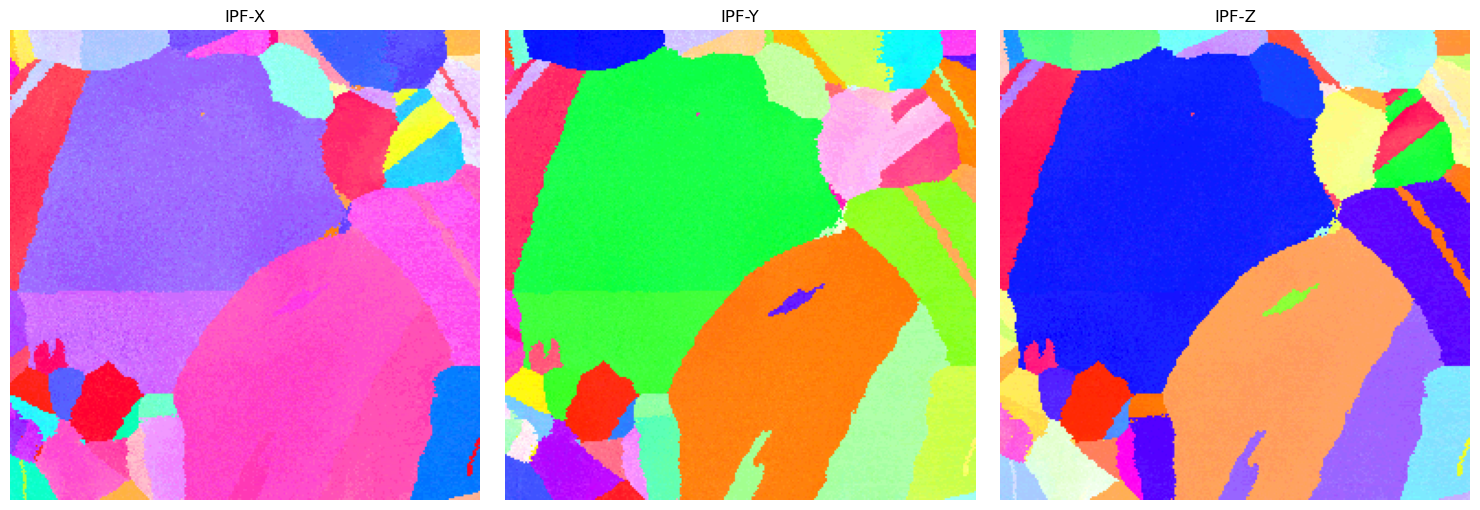

In [ ]:
# plot patch IPF map to visually confirm it's the blue grain
# use visualization folder from repo for IPF plotting
from visualization.ipf_render import render_ipf_rgb
from utils.symmetry_utils import resolve_symmetry
import matplotlib.pyplot as plt

# Resolve orix Symmetry object (use 'Oh' for FCC / cubic)
sym = resolve_symmetry('Oh')

# Get IPF RGB maps for X, Y, Z (returns list of 3 arrays)
ipf_rgb = render_ipf_rgb(candidate, sym)

if isinstance(ipf_rgb, list) and len(ipf_rgb) == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, name in zip(axes, ipf_rgb, ("X", "Y", "Z")):
        ax.imshow(img)
        ax.set_title(f"IPF-{name}")
        ax.set_aspect("equal", adjustable="box")
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    plt.imshow(ipf_rgb)
    plt.title("IPF Map")
    plt.axis('off')
    plt.show()

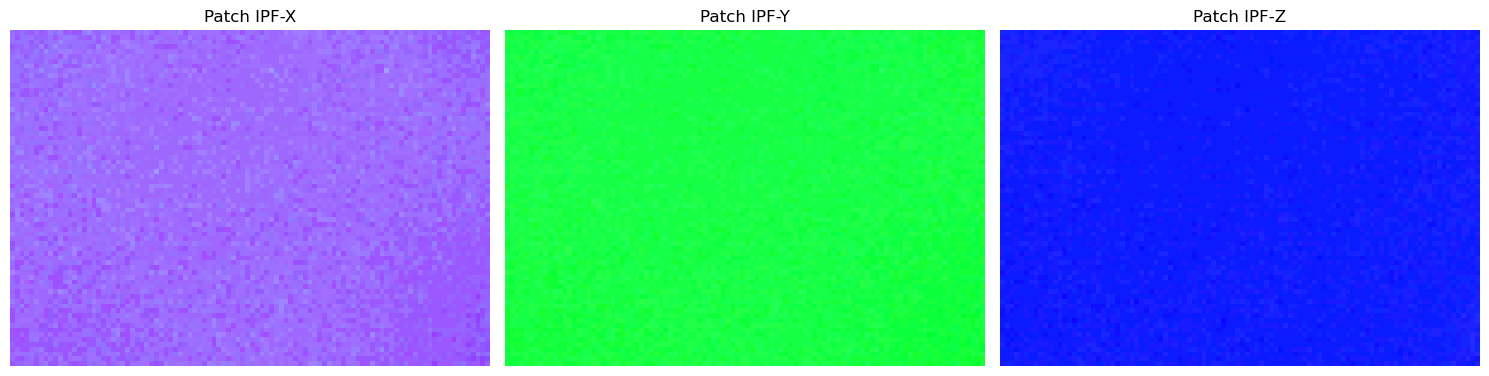

In [ ]:
# Create a grain mask for the blue grain (manually thresholding the IPF map)
q_patch_mod = candidate[50:120, 50:150]  # shape (h,w,4)

# plot IPF map for the patch to visually confirm the grain structure
ipf_patch_rgb = render_ipf_rgb(q_patch_mod, sym)
if isinstance(ipf_patch_rgb, list) and len(ipf_patch_rgb) == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, name in zip(axes, ipf_patch_rgb, ("X", "Y", "Z")):
        ax.imshow(img)
        ax.set_title(f"Patch IPF-{name}")
        ax.set_aspect("equal", adjustable="box")
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
candidate_lr_file = "/data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_4x1/Train/LR_Data/IN718_QSR_4x1_train_lr_x_block_338.npy"
candidate_lr = np.load(candidate_lr_file)  # shape (H, W, 4)

# run inference on candidate_lr to get candidate_sr (this would be your model's output)
# use "/data/home/umang/Materials/Reynolds-QSR_4x1/inference/infer_iso_embedding_sr_attn.py"



In [ ]:
import importlib.util
from pathlib import Path

p = Path("/data/home/umang/Materials/Reynolds-QSR_4x1/inference/infer_iso_embedding_sr_attn.py")
spec = importlib.util.spec_from_file_location("infmod", str(p))
inf = importlib.util.module_from_spec(spec)
spec.loader.exec_module(inf)

In [ ]:
from pathlib import Path
import numpy as np
import torch
from inference import infer_iso_embedding_sr_attn as inf
from training.config_utils import load_and_prepare_config

# point this to your experiment dir (contains config.json & checkpoints)
exp_dir = Path("/data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_sr_attn_01")
cfg_path = exp_dir / "config_new.json"
run_cfg = exp_dir / "logs" / "inference_run_config.json"
assert cfg_path.exists(), f"Config missing: {cfg_path}"
assert run_cfg.exists(), f"Run config missing: {run_cfg}"
cfg = load_and_prepare_config(cfg_path, run_cfg)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = inf._resolve_checkpoint(cfg, exp_dir, "best_model.pt")
model = inf._load_model_from_checkpoint(cfg, checkpoint, device)

# your LR file
candidate_lr_file = "/data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_4x1/Train/LR_Data/IN718_QSR_4x1_train_lr_x_block_338.npy"
candidate_hr_file = "/data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_4x1/Train/HR_Data/IN718_QSR_4x1_train_hr_x_block_338.npy"
lr = np.load(candidate_lr_file).astype(np.float32)   # expected shape (H, W, 4)
hr = np.load(candidate_hr_file).astype(np.float32)   # expected shape (H, W, 4)
lr_t = torch.from_numpy(lr).to(device=device, dtype=torch.float32)

# prepare and run
lr_flat, lr_shape = inf._flatten_quat_chw(lr_t)
with torch.enable_grad():
    sr_flat = model.forward_sr(lr_flat, lr_shape=lr_shape, normalize_input=True)


Using symmetry group from config: Oh
Overridden config values:
  - dataset_root: /data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_4x1 (default: )
  - epochs: 150 (default: 10)
  - batch_size: 5 (default: 4)
  - scale: [4, 1] (default: 4)
  - symmetry_group: Oh (default: O)
  - use_lr_conv2: False (default: True)
  - num_hr_attn_blocks: 0 (default: 1)
  - hr_attn_num_channels: 4 (default: 8)
  - hr_attn_block_size: 32 (default: 16)
  - hr_attn_tp_out_chunk_size: 128 (default: 2048)
  - decoder_num_starts: 4 (default: 2)
  - decoder_steps: 30 (default: 1)
  - decoder_lr: 0.03 (default: 0.05)
  - num_workers: 8 (default: 0)
  - preload: True (default: False)
  - preload_torch: True (default: False)
  - min_free_cuda_gb: 4.0 (default: 0.0)
Using existing symmetry files for Oh
Saved resolved config to /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_sr_attn_01/logs/inference_run_config.json
Model: models.SR_double_conv_SRattn_a1.IsoEmbeddingSRAtt

In [ ]:
print("LR flat shape:", lr_flat.shape)
print("SR flat shape:", sr_flat.shape)
print("Scale:", sr_flat.shape[0] / lr_flat.shape[0])

LR flat shape: torch.Size([16384, 4])
SR flat shape: torch.Size([65536, 4])
Scale: 4.0


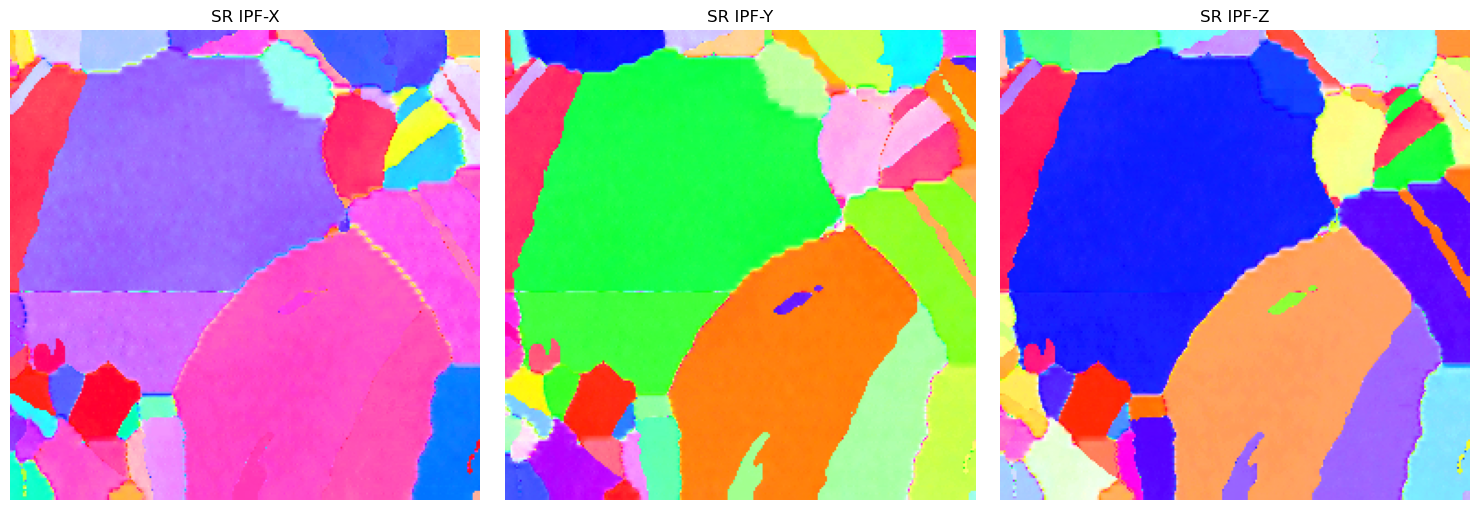

In [ ]:
# plot the SR IPF map for the patch to visually confirm the grain structure is preserved
sr_flat_cpu = sr_flat.cpu().detach().numpy()
hr_shape= hr.shape
# reshape to (H, W, 4) using hr_shape
sr_cpu = sr_flat_cpu.reshape(hr_shape[0], hr_shape[1], 4)
# render IPF map for the SR output
sr_ipf_rgb = render_ipf_rgb(sr_cpu, sym)
if isinstance(sr_ipf_rgb, list) and len(sr_ipf_rgb) == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, name in zip(axes, sr_ipf_rgb, ("X", "Y", "Z")):
        ax.imshow(img)
        ax.set_title(f"SR IPF-{name}")
        ax.set_aspect("equal", adjustable="box")
        ax.axis('off')
    plt.tight_layout()
    plt.show()



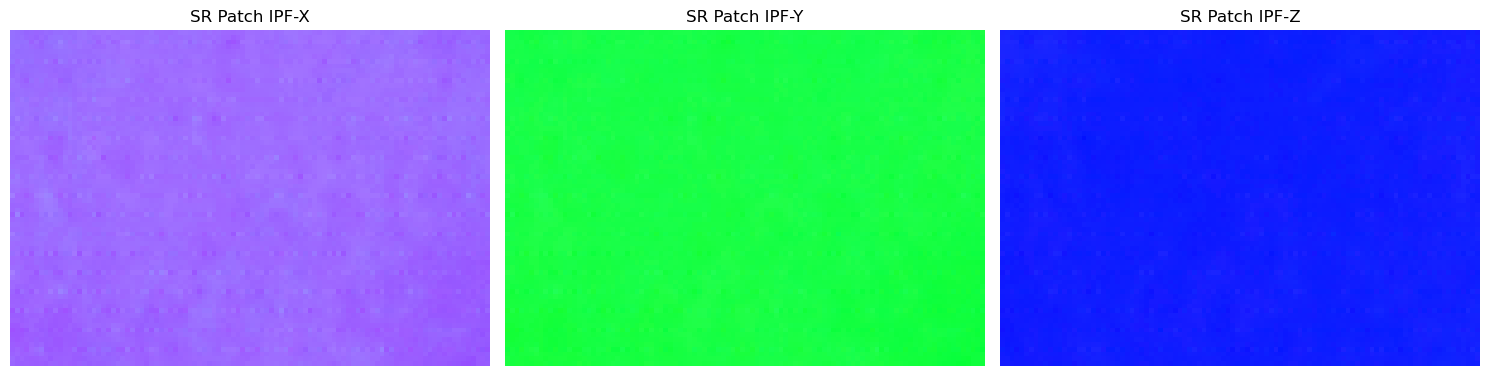

In [ ]:
candidate_patch_sr = sr_cpu[50:120, 50:150]  # shape (h,w,4)
#Plot IPF map for the SR patch to visually confirm the grain structure
sr_patch_ipf_rgb = render_ipf_rgb(candidate_patch_sr, sym)
if isinstance(sr_patch_ipf_rgb, list) and len(sr_patch_ipf_rgb) == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, name in zip(axes, sr_patch_ipf_rgb, ("X", "Y", "Z")):
        ax.imshow(img)
        ax.set_title(f"SR Patch IPF-{name}")
        ax.set_aspect("equal", adjustable="box")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# #Run GROD and KAM on the SR patch and compare to HR patch
# grod_sr, grod_stats_sr = compute_grod(candidate_patch_sr, sym_ops=sym)
# grod_hr, grod_stats_hr = compute_grod(q_patch_mod, sym_ops=sym)
# kam_sr, kam_stats_sr = compute_kam(candidate_patch_sr, radius=1, sym_ops=sym)
# kam_hr, kam_stats_hr = compute_kam(q_patch_mod, radius=1, sym_ops=sym)

/tmp/ipykernel_874056/3023747805.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


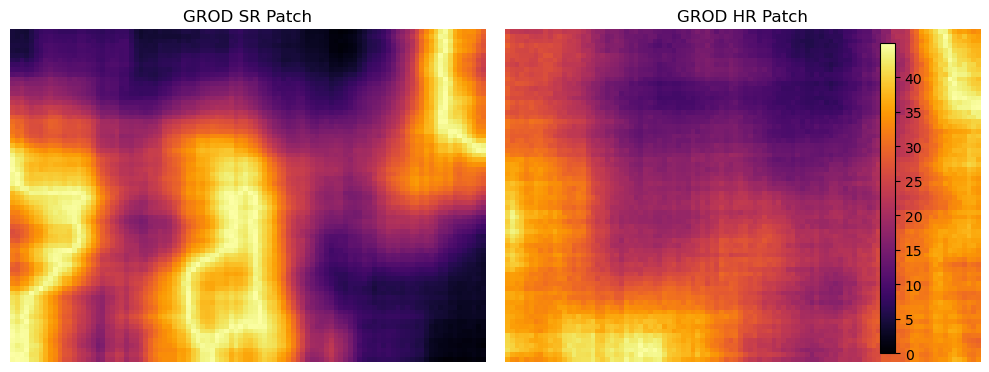

In [ ]:
# # Plot GROD maps for SR and HR patches
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# im0 = axes[0].imshow(grod_sr, cmap='inferno', vmin=0, vmax=np.nanmax(grod_sr))
# axes[0].set_title("GROD SR Patch")
# axes[0].axis('off')
# im1 = axes[1].imshow(grod_hr, cmap='inferno', vmin=0, vmax=np.nanmax(grod_hr))
# axes[1].set_title("GROD HR Patch")
# axes[1].axis('off')
# fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02)
# plt.tight_layout()
# plt.show()

/tmp/ipykernel_874056/3645606076.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


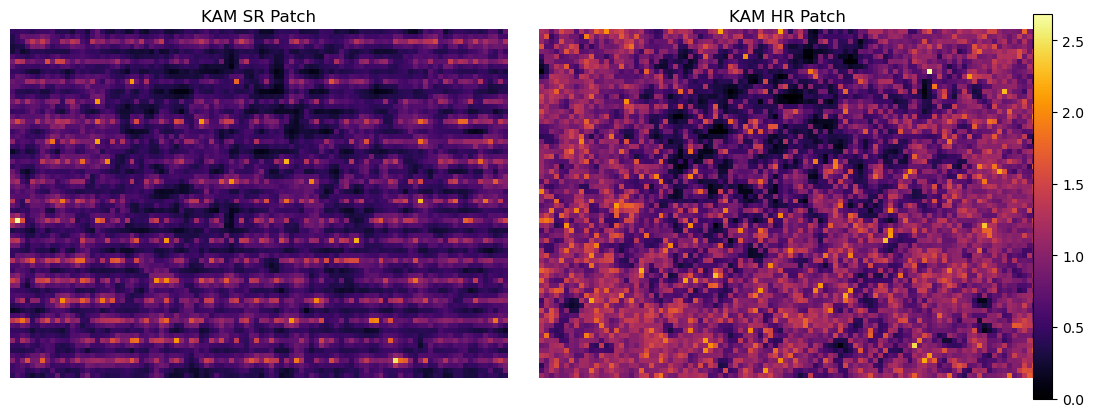

In [ ]:
# # Plot KAM maps for SR and HR patches with colorbar outside the plots
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# im0 = axes[0].imshow(kam_sr, cmap='inferno', vmin=0, vmax=np.nanmax(kam_sr))
# im1 = axes[1].imshow(kam_hr, cmap='inferno', vmin=0, vmax=np.nanmax(kam_hr))
# axes[0].set_title("KAM SR Patch")
# axes[0].axis('off')
# axes[1].set_title("KAM HR Patch")
# axes[1].axis('off')

# # Place colorbar outside the right of the plots
# cbar = fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.045, pad=0.15, location='right')
# plt.tight_layout(rect=[0, 0, 0.88, 1])
# plt.show()

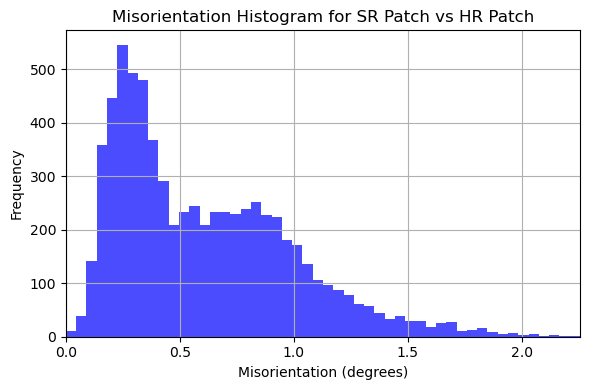

In [ ]:
# Check if all orientations are correct in SR patch (i.e. misorientation to HR patch is small)
# plot the misorientation histogram for the SR patch vs HR patch
mis_patch = crystallographic_misorientation(candidate_patch_sr, q_patch_mod, sym_quats=sym, degrees=True)
plt.figure(figsize=(6, 4))
plt.hist(mis_patch.flatten(), bins=50, range=(0, np.nanmax(mis_patch)), color='blue', alpha=0.7)
plt.title("Misorientation Histogram for SR Patch vs HR Patch")
plt.xlabel("Misorientation (degrees)")
plt.ylabel("Frequency")
plt.xlim(0, np.nanmax(mis_patch))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import cv2

def bicubic_interpolate_quaternions(lr_patch, scale_y=4, scale_x=1):
    """Perform bicubic interpolation on quaternion data by interpolating each component separately and re-normalizing.
    scale_y: scale factor for height (default 4)
    scale_x: scale factor for width (default 1)
    """
    h_lr, w_lr, _ = lr_patch.shape
    h_tgt = int(h_lr * scale_y)
    w_tgt = int(w_lr * scale_x)
    sr_patch = np.zeros((h_tgt, w_tgt, 4), dtype=np.float32)
    for i in range(4):
        sr_patch[..., i] = cv2.resize(lr_patch[..., i], (w_tgt, h_tgt), interpolation=cv2.INTER_CUBIC)
    # re-normalize to unit quaternions
    norms = np.linalg.norm(sr_patch, axis=-1, keepdims=True)
    norms[norms == 0] = 1.0  # prevent division by zero
    sr_patch /= norms
    return sr_patch


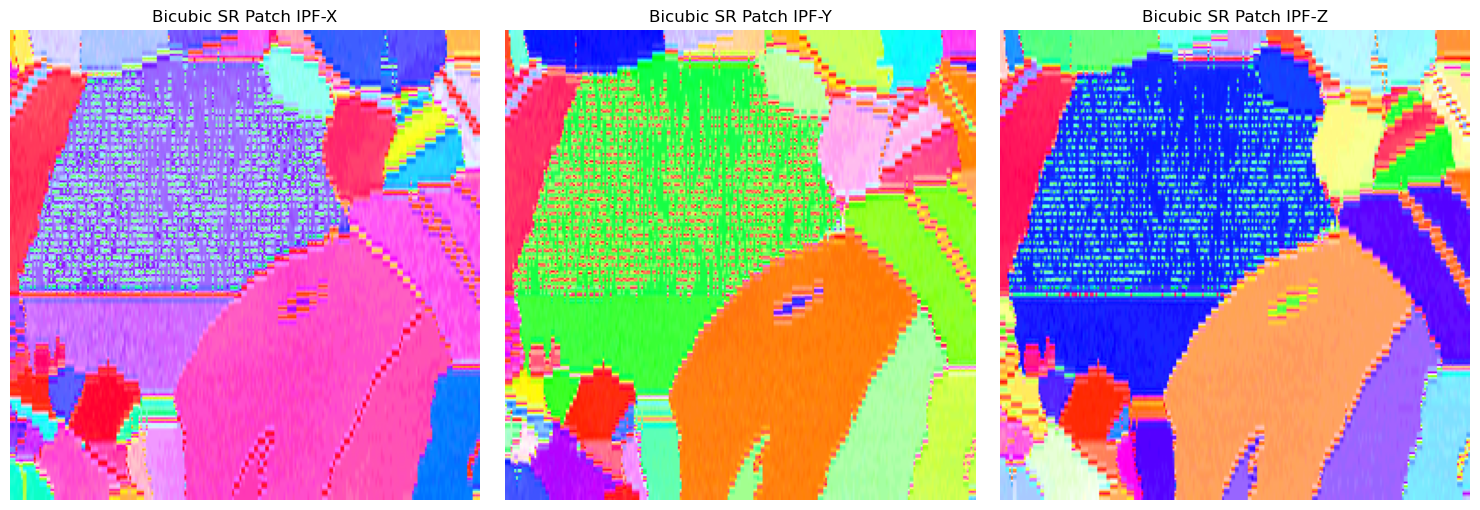

In [ ]:
sr_patch_bicubic = bicubic_interpolate_quaternions(candidate_lr)

# plot the bicubic SR patch IPF map to visually confirm the grain structure
bicubic_ipf_rgb = render_ipf_rgb(sr_patch_bicubic, sym)
if isinstance(bicubic_ipf_rgb, list) and len(bicubic_ipf_rgb) == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, name in zip(axes, bicubic_ipf_rgb, ("X", "Y", "Z")):
        ax.imshow(img)
        ax.set_title(f"Bicubic SR Patch IPF-{name}")
        ax.set_aspect("equal", adjustable="box")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

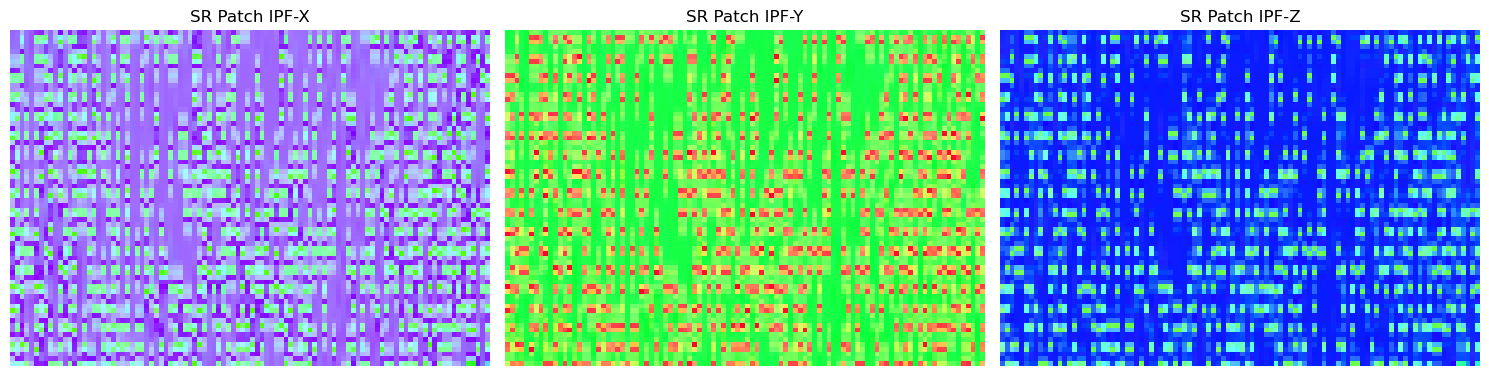

In [ ]:
candidate_patch_sr = sr_patch_bicubic[50:120, 50:150]  # shape (h,w,4)
#Plot IPF map for the SR patch to visually confirm the grain structure
sr_patch_ipf_rgb = render_ipf_rgb(candidate_patch_sr, sym)
if isinstance(sr_patch_ipf_rgb, list) and len(sr_patch_ipf_rgb) == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, name in zip(axes, sr_patch_ipf_rgb, ("X", "Y", "Z")):
        ax.imshow(img)
        ax.set_title(f"SR Patch IPF-{name}")
        ax.set_aspect("equal", adjustable="box")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

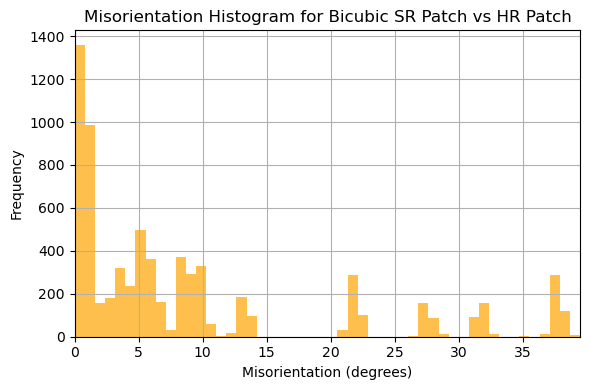

In [ ]:
# Now do misorientation histogram for bicubic SR patch vs HR patch
mis_patch_bicubic = crystallographic_misorientation(candidate_patch_sr, q_patch_mod, sym_quats=sym, degrees=True)
plt.figure(figsize=(6, 4))
plt.hist(mis_patch_bicubic.flatten(), bins=50, range=(0, np.nanmax(mis_patch_bicubic)), color='orange', alpha=0.7)
plt.title("Misorientation Histogram for Bicubic SR Patch vs HR Patch")
plt.xlabel("Misorientation (degrees)")
plt.ylabel("Frequency")
plt.xlim(0, np.nanmax(mis_patch_bicubic))
plt.grid(True)
plt.tight_layout()
plt.show()

### Bicubic on ISO embeddings

### Symm-SLERP

### SLERP 


### QEDSR



### QRBSA